**🌐 Language:** [English →](/fuzzy-rdd-en) | **한국어**

# Fuzzy Regression Discontinuity

<small><em>작성자 손지우 · <a href="https://github.com/bungaedm">GitHub</a> · <a href="https://www.linkedin.com/in/jiwoo-son-3207021a7/">LinkedIn</a></em></small>

In [6]:
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings(action='ignore')

In [7]:
%load_ext autoreload
%autoreload 2

from src.rdd import *
from src.fuzzy_rdd import *
from src.image import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Recap

## RDD란

RDD (Regression Discontinuity Design)은 특정 기준점(Cutoff)을 기준으로 처치(Treatment, 정책/혜택 등)를 받는 집단과 받지 않는 집단을 나누어, 그 기준점 근처의 데이터를 비교함으로써 인과 효과를 추정하는 준실험적 방법론(Quasi-experimental method)입니다

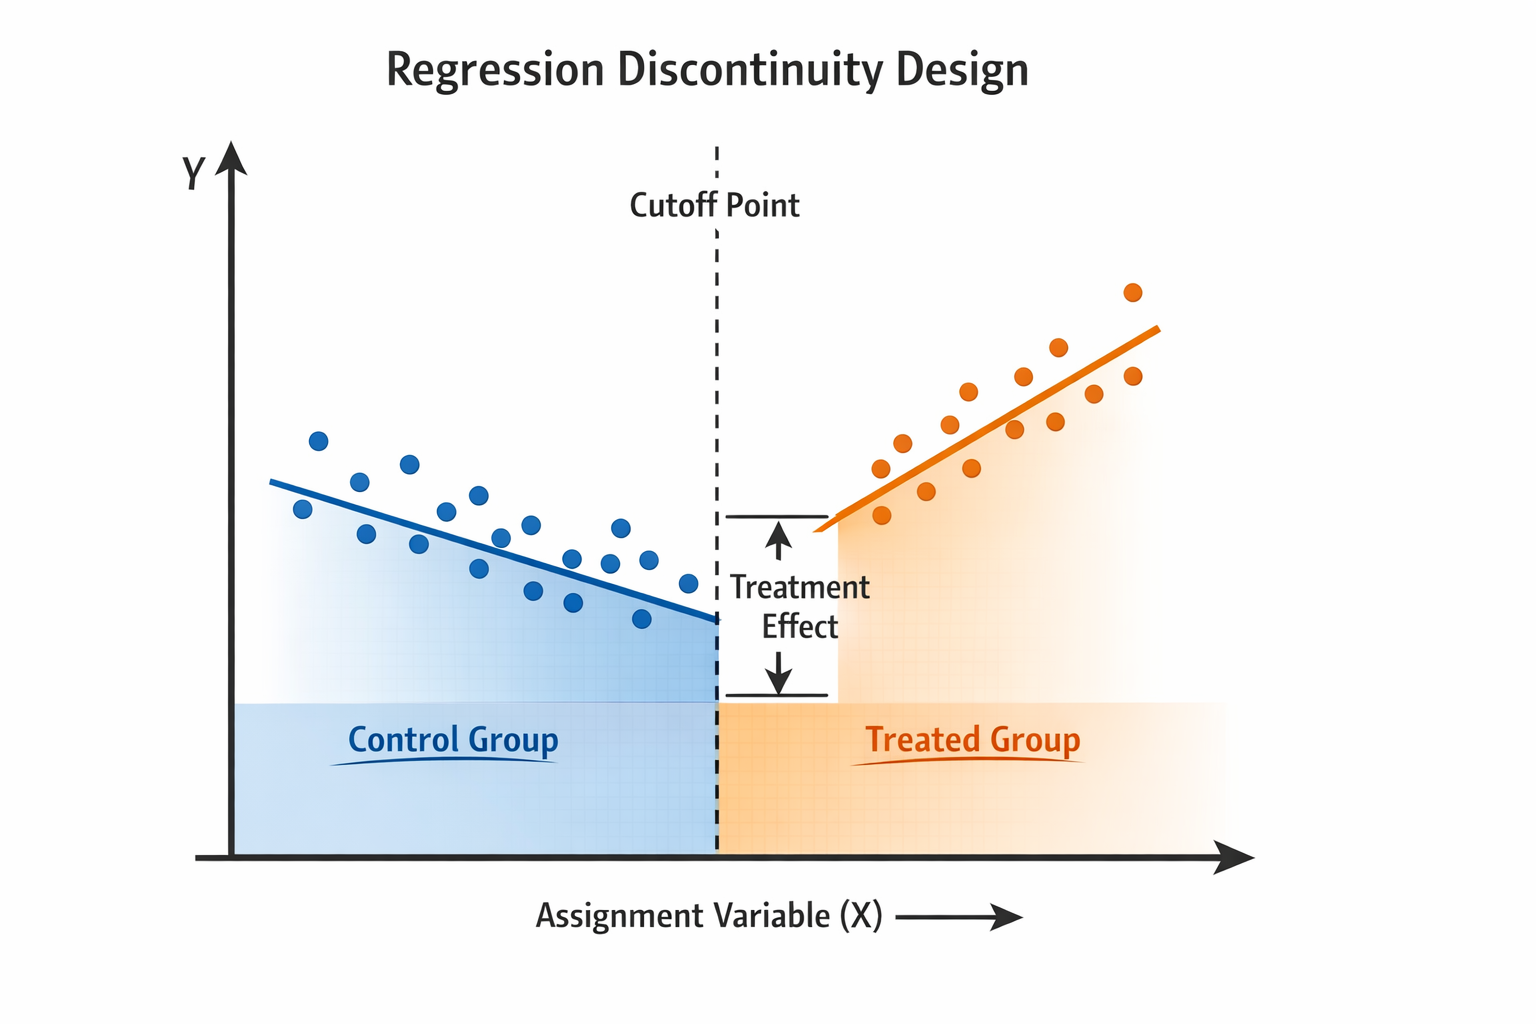

In [8]:
show_image('rdd.png')

## RDD 종류 (Sharp & Fuzzy)

RDD는 크게 Sharp Design과 Fuzzy Design으로 나뉜다.

* `Sharp Design`은 임계값을 기준으로 처치 여부가 완전히 결정되는 경우이고,
* `Fuzzy Design`은 임계값이 처치 확률에는 영향을 주지만 실제 처치 여부가 완전히 일치하지는 않는 경우를 의미한다.

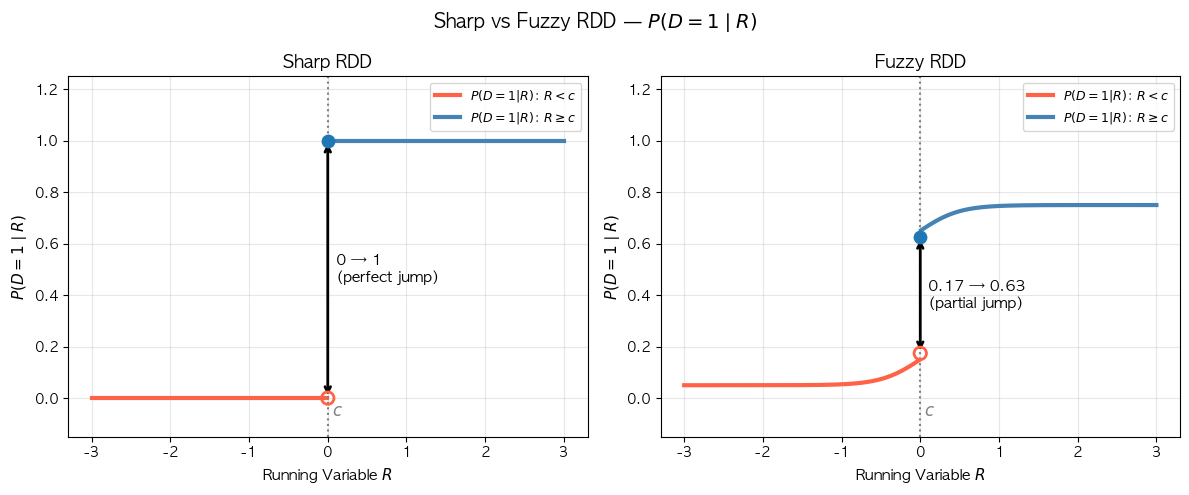

In [9]:
plot_rdd_type()

# Fuzzy RD

## 간단요약

Fuzzy RD는 임계값(cutoff) 근처에서 처치 확률이 불연속적으로 변하지만, 처치 배정이 완벽하지 않은 (완전 순응하지 않는) 경우에 사용합니다. 이때 2SLS로 LATE(Local Average Treatment Effect)를 추정합니다.

[First Stage]  α₁ (Z→D jump) = 0.6077,  F-stat = 220.14
[LATE (2SLS)]  β₁ = 0.3176  SE = 0.0892
[95% CI]       [0.1426, 0.4925]
[Wald]         0.3162
[ITT_Y]        0.1922   [ITT_D]  0.6077


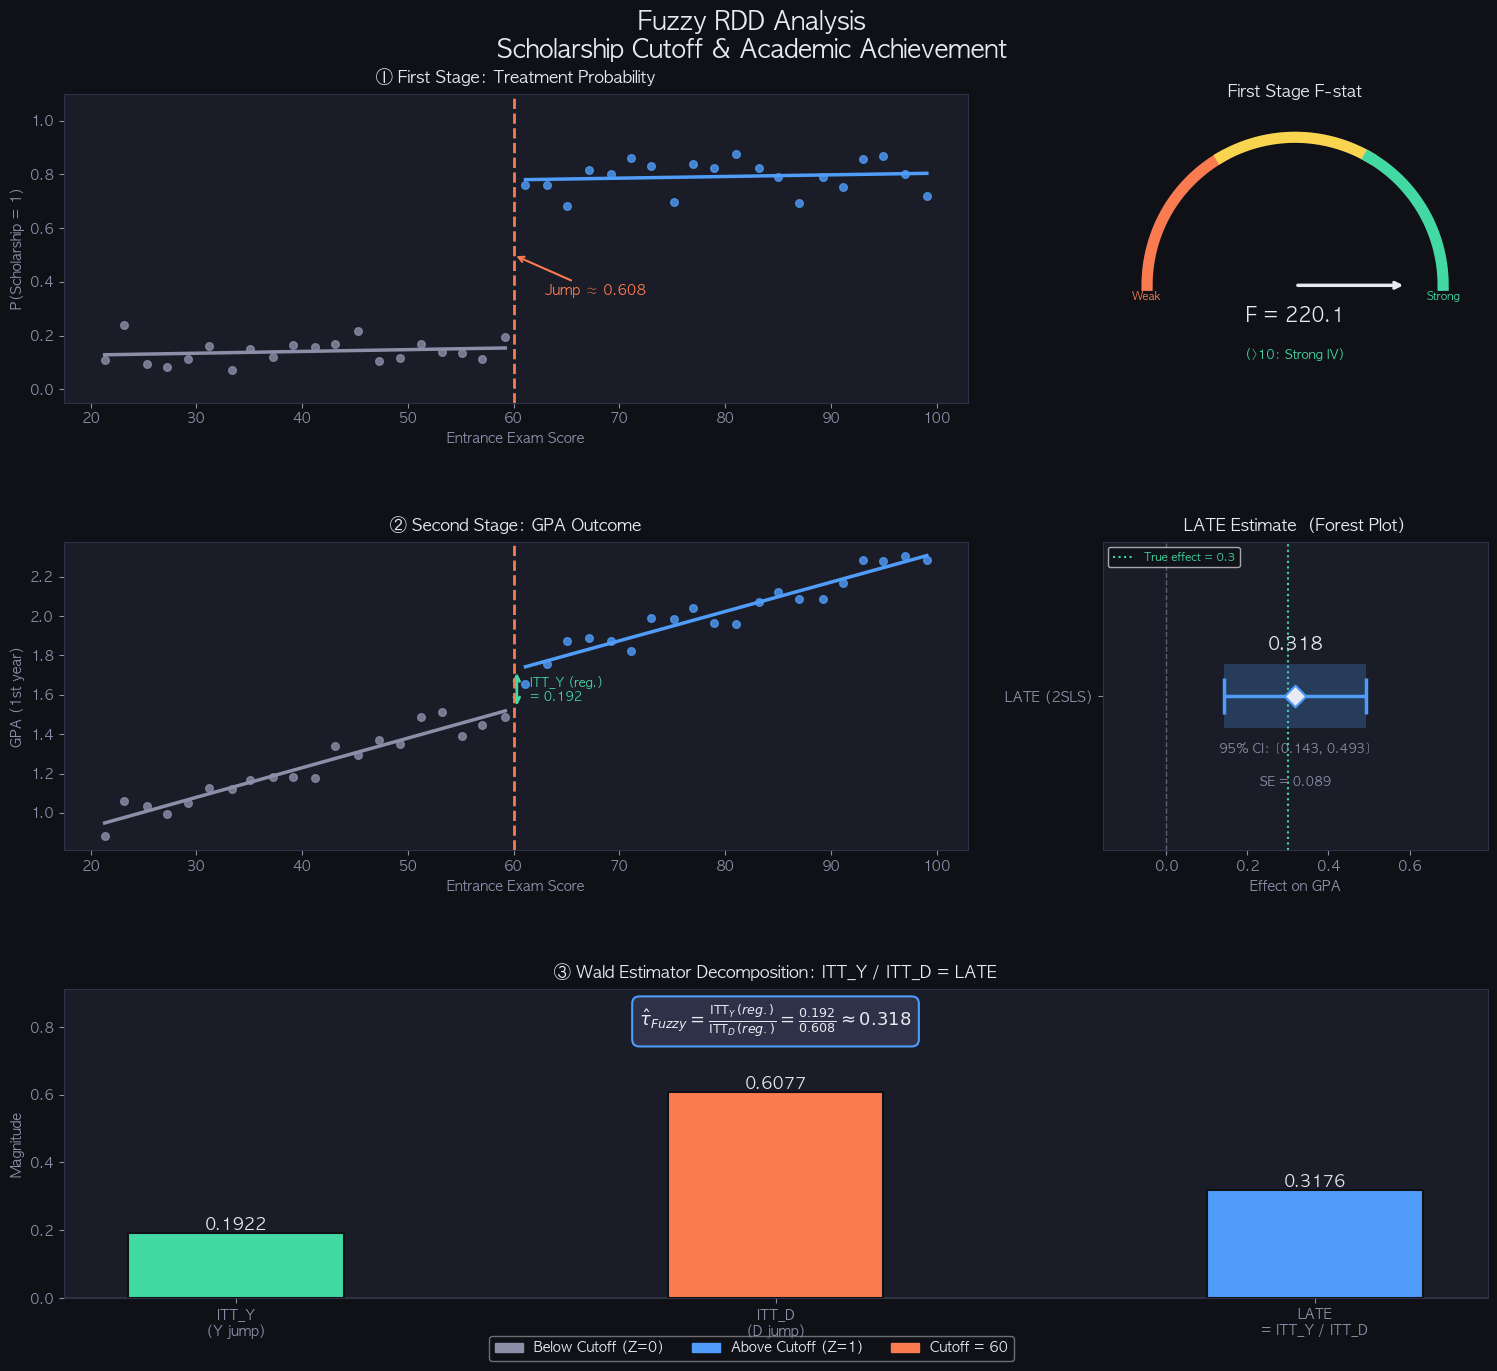

In [10]:
plot_fuzzy_rdd(true_effect=0.3)

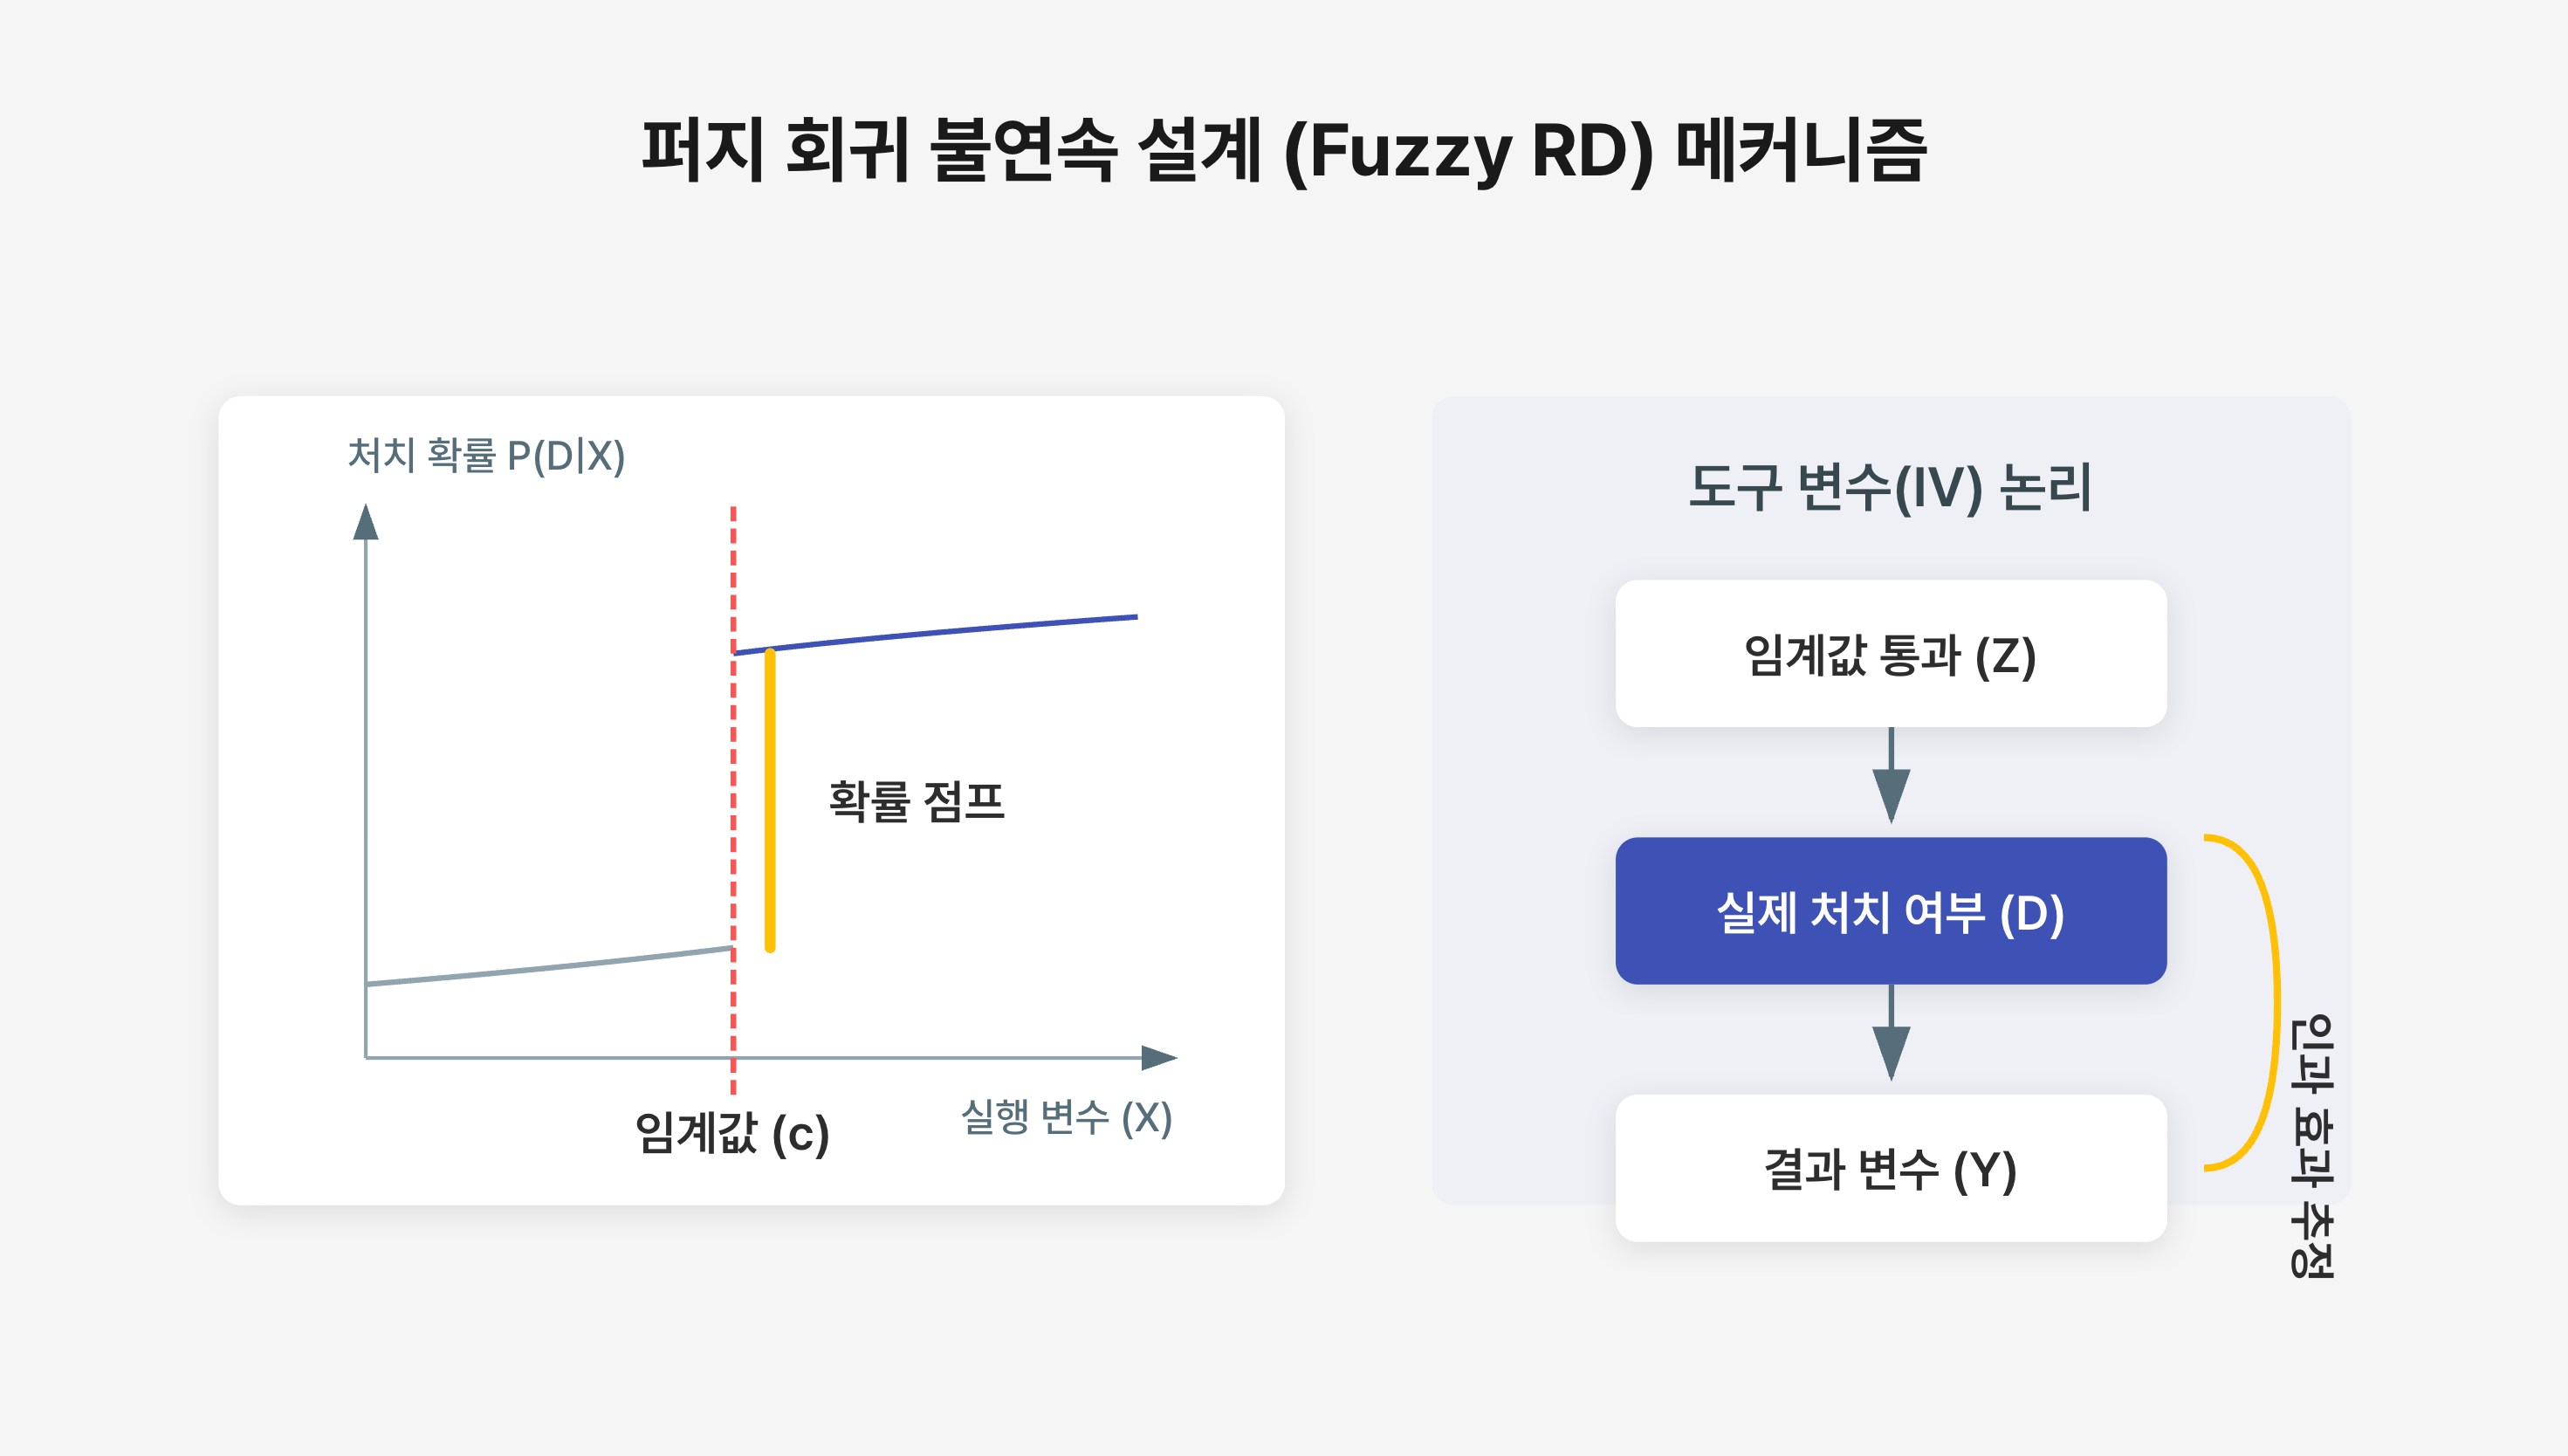

In [11]:
show_image('rdd_fuzzy_01.png')

## 기본 설정

- $X_i$: 연속형 실행 변수 (running variable)
- $c$: 임계값 (cutoff)
- $D_i$: 실제 처치 여부 (binary, $D_i \in \{0, 1\}$)
- $Z_i = \mathbf{1}[X_i \geq c]$: 도구변수 (임계값 초과 여부)
- $Y_i$: 결과 변수

Sharp RD와 달리, Fuzzy RD에서는 임계값에서 **처치 확률**이 불연속적으로 변합니다:

$$\lim_{x \rightarrow c-} \Pr(D_i = 1 \mid X_i = x) \neq \lim_{x \rightarrow c+} \Pr(D_i = 1 \mid X_i = x)$$

단, 처치 확률의 점프가 완전하지 않으므로 ($\neq 0$ 또는 $1$), $Z_i$를 도구변수로 활용합니다.

## 식별 가정 (Identification Assumptions)

| 가정 | 내용 |
|------|------|
| **연속성 (Continuity)** | $\mathbb{E}[Y_i(0) \mid X_i = x]$, $\mathbb{E}[Y_i(1) \mid X_i = x]$ 가 $x = c$에서 연속 |
| **관련성 (Relevance)** | $Z_i$가 $D_i$에 유의한 영향: $\alpha_1 \neq 0$ |
| **배제 제약 (Exclusion)** | $Z_i$는 $D_i$를 통해서만 $Y_i$에 영향 |
| **단조성 (Monotonicity)** | $D_i(Z=1) \geq D_i(Z=0)$ (비위반자 없음) |

## 추정

### 추정 대상: LATE

$$\beta_1 = \mathbb{E}[Y_i(1) - Y_i(0) \mid \text{complier}, X_i = c]$$

이는 임계값 $c$ **근방**에 위치한 순응자(compliers)에 대한 처치효과이며, 모집단 전체의 ATE와는 다를 수 있습니다.

### 2SLS 추정: 두 단계

* 2단계 최소제곱법(2SLS)을 통해 분석을 수행한다.
    * 1단계 (First Stage): 러닝 변수가 컷오프보다 큰지 여부를 도구 변수로 활용하여 실제 트리트먼트 여부를 예측한다. 
    * 2단계 (Second Stage): 1단계에서 예측된 트리트먼트를 활용하여 결과 변수에 미치는 효과를 분석한다. 

`1단계 (First Stage)`: 처치 여부 회귀

$$D_i = \alpha_0 + \alpha_1 Z_i + \alpha_2 (X_i - c) + \alpha_3 Z_i (X_i - c) + \epsilon_i^{(1)}$$

- $Z_i = \mathbf{1}[X_i \geq c]$가 $D_i$에 미치는 불연속 효과를 추정
- 추정된 처치값: $\hat{D}_i$
- 핵심 가정: **관련성(Relevance)** — $\alpha_1 \neq 0$
    - $\alpha_1$: 임계값을 기준으로 처치 확률이 얼마나 점프하는지
    - 만약 $\alpha_1 \approx 0$ 이라면, $Z_i$가 $D_i$를 거의 설명하지 못한다는 뜻이고, 이경우 2단계 추정량 $\beta_1$의 분산이 폭발적으로 커져서 신뢰할 수 없게 됩니다.

`2단계 (Second Stage)`: 결과 변수 회귀

$$Y_i = \beta_0 + \beta_1 \hat{D}_i + \beta_2 (X_i - c) + \beta_3 \hat{D}_i (X_i - c) + \epsilon_i^{(2)}$$

- $\beta_1$: **LATE (Local Average Treatment Effect)** 추정값
- 임계값 $c$ 근방의 순응자(compliers)에 대한 인과효과

### Wald 추정량으로의 표현

2SLS 추정량은 임계값에서의 **Wald 추정량**과 동일합니다:

$$\hat{\tau}_{Fuzzy} = \frac{\text{ITT}_Y}{\text{ITT}_D} = \frac{\lim_{x \rightarrow c+} \mathbb{E}[Y_i \mid X_i = x] - \lim_{x \rightarrow c-} \mathbb{E}[Y_i \mid X_i = x]}{\lim_{x \rightarrow c+} \mathbb{E}[D_i \mid X_i = x] - \lim_{x \rightarrow c-} \mathbb{E}[D_i \mid X_i = x]}$$

- **$\text{ITT}_Y$**: $Z_i$가 **결과변수** $Y_i$에 미치는 효과

$$\text{ITT}_Y = \lim_{x \downarrow c} \mathbb{E}[Y_i \mid X_i = x] - \lim_{x \uparrow c} \mathbb{E}[Y_i \mid X_i = x]$$

- **$\text{ITT}_D$**: $Z_i$가 **실제 처치** $D_i$에 미치는 효과

$$\text{ITT}_D = \lim_{x \downarrow c} \mathbb{E}[D_i \mid X_i = x] - \lim_{x \uparrow c} \mathbb{E}[D_i \mid X_i = x]$$

예를 들어 장학금 기준 점수를 넘은 학생 중 일부만 실제로 장학금을 신청·수령했다면:

| | 기준 미달 | 기준 초과 |
|---|---|---|
| 실제 수혜율 | 10% | 60% |
| 성적 향상 | 2점 | 5점 |

- $\text{ITT}_D = 0.6 - 0.1 = 0.5$ (처치 확률 점프)
- $\text{ITT}_Y = 5 - 2 = 3$점 (성적 점프)
- $\text{LATE} = \dfrac{3}{0.5} = 6$점 $\leftarrow$ **실제로 순응한 사람들의 효과**

## 유의사항

* 시각화: 산점도와 회귀선을 그려 기준점에서 불연속적인 점프가 있는지 확인하는 것이 중요합니다.
* 연속성 검증: 기준점 바로 위아래의 공변량(연령, 성별 등)이 유사한지 확인해야 합니다.
* 대역폭(Bandwidth) 선택: 기준점에서 너무 먼 데이터는 영향을 줄여야 하므로 적절한 범위를 설정해야 합니다.

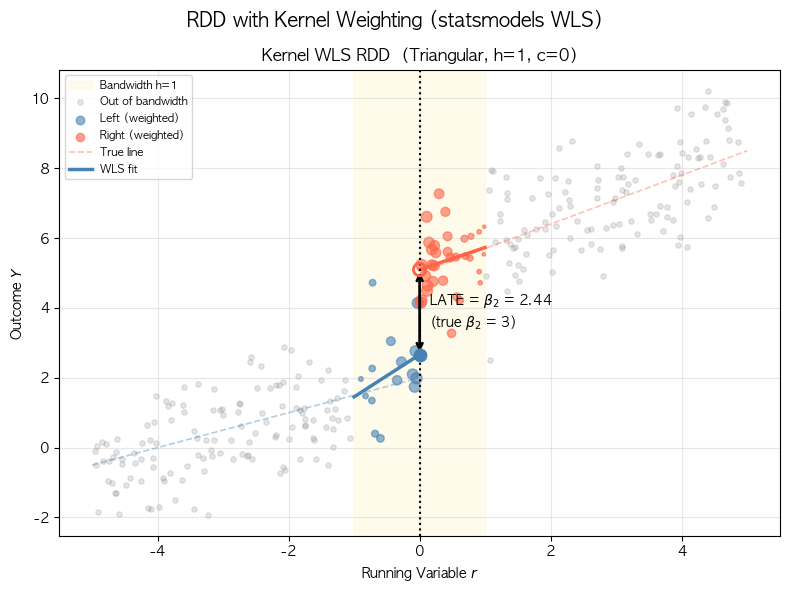

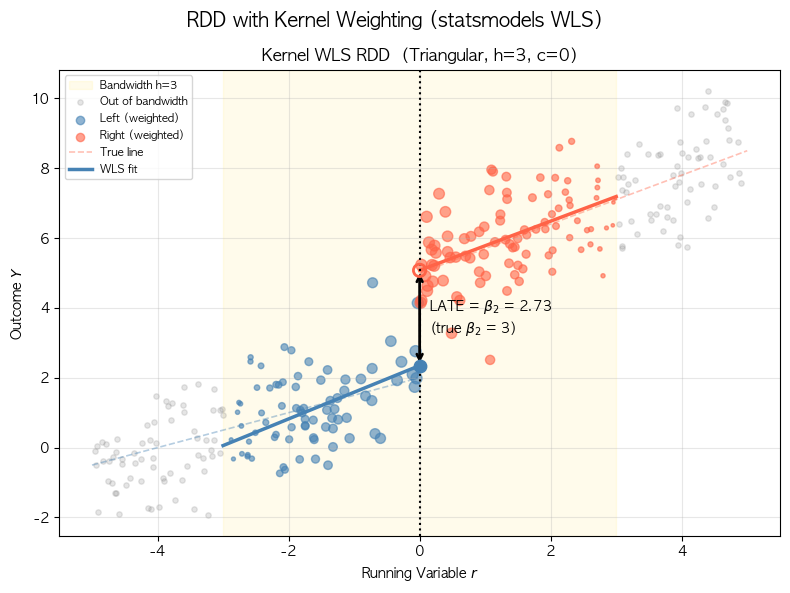

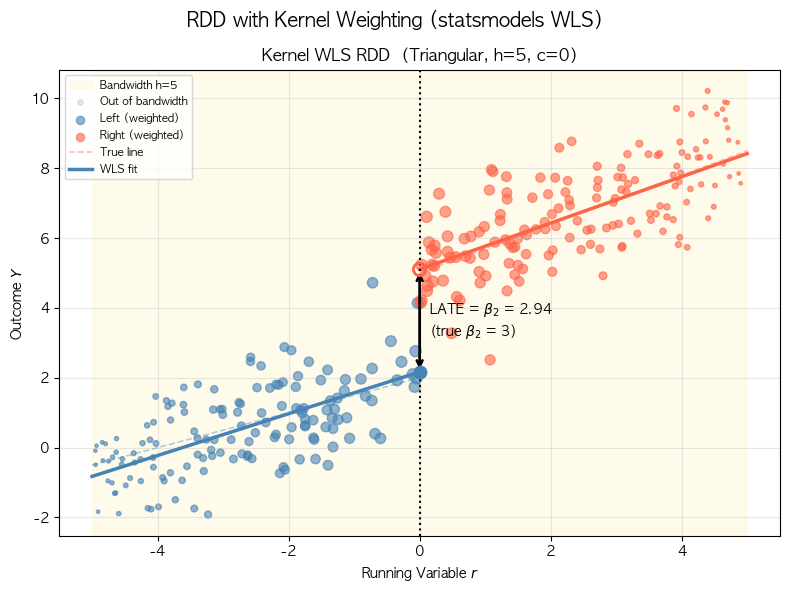

In [12]:
# Bandwidth에 따른 차이
plot_rdd_kernel(bandwidth=1, kernel='triangular', show_kernel=False)
plot_rdd_kernel(bandwidth=3, kernel='triangular', show_kernel=False)
plot_rdd_kernel(bandwidth=5, kernel='triangular', show_kernel=False)

## 장단점

* 장점
    * 무작위 배정(RCT)이 불가능한 현실 상황(정책, 프로모션 등)에서 강력한 인과 추론이 가능합니다.
* 단점/제약:
    * 국소적 효과: 기준점 근처의 대상자들에 대한 효과만 파악 가능하며, 전체 인구로 일반화하기 어려울 수 있습니다.
    * 조작 가능성: 사람들이 기준점을 넘기 위해 할당 변수(점수 등)를 조작할 경우 인과 추론이 불가능해집니다.
    

# 코드 예시

[First Stage]  α₁ (Z→D jump) = 0.6077,  F-stat = 220.14
[LATE (2SLS)]  β₁ = 0.8176  SE = 0.1073
[95% CI]       [0.6070, 1.0282]
[Wald]         0.8162
[ITT_Y]        0.4960   [ITT_D]  0.6077


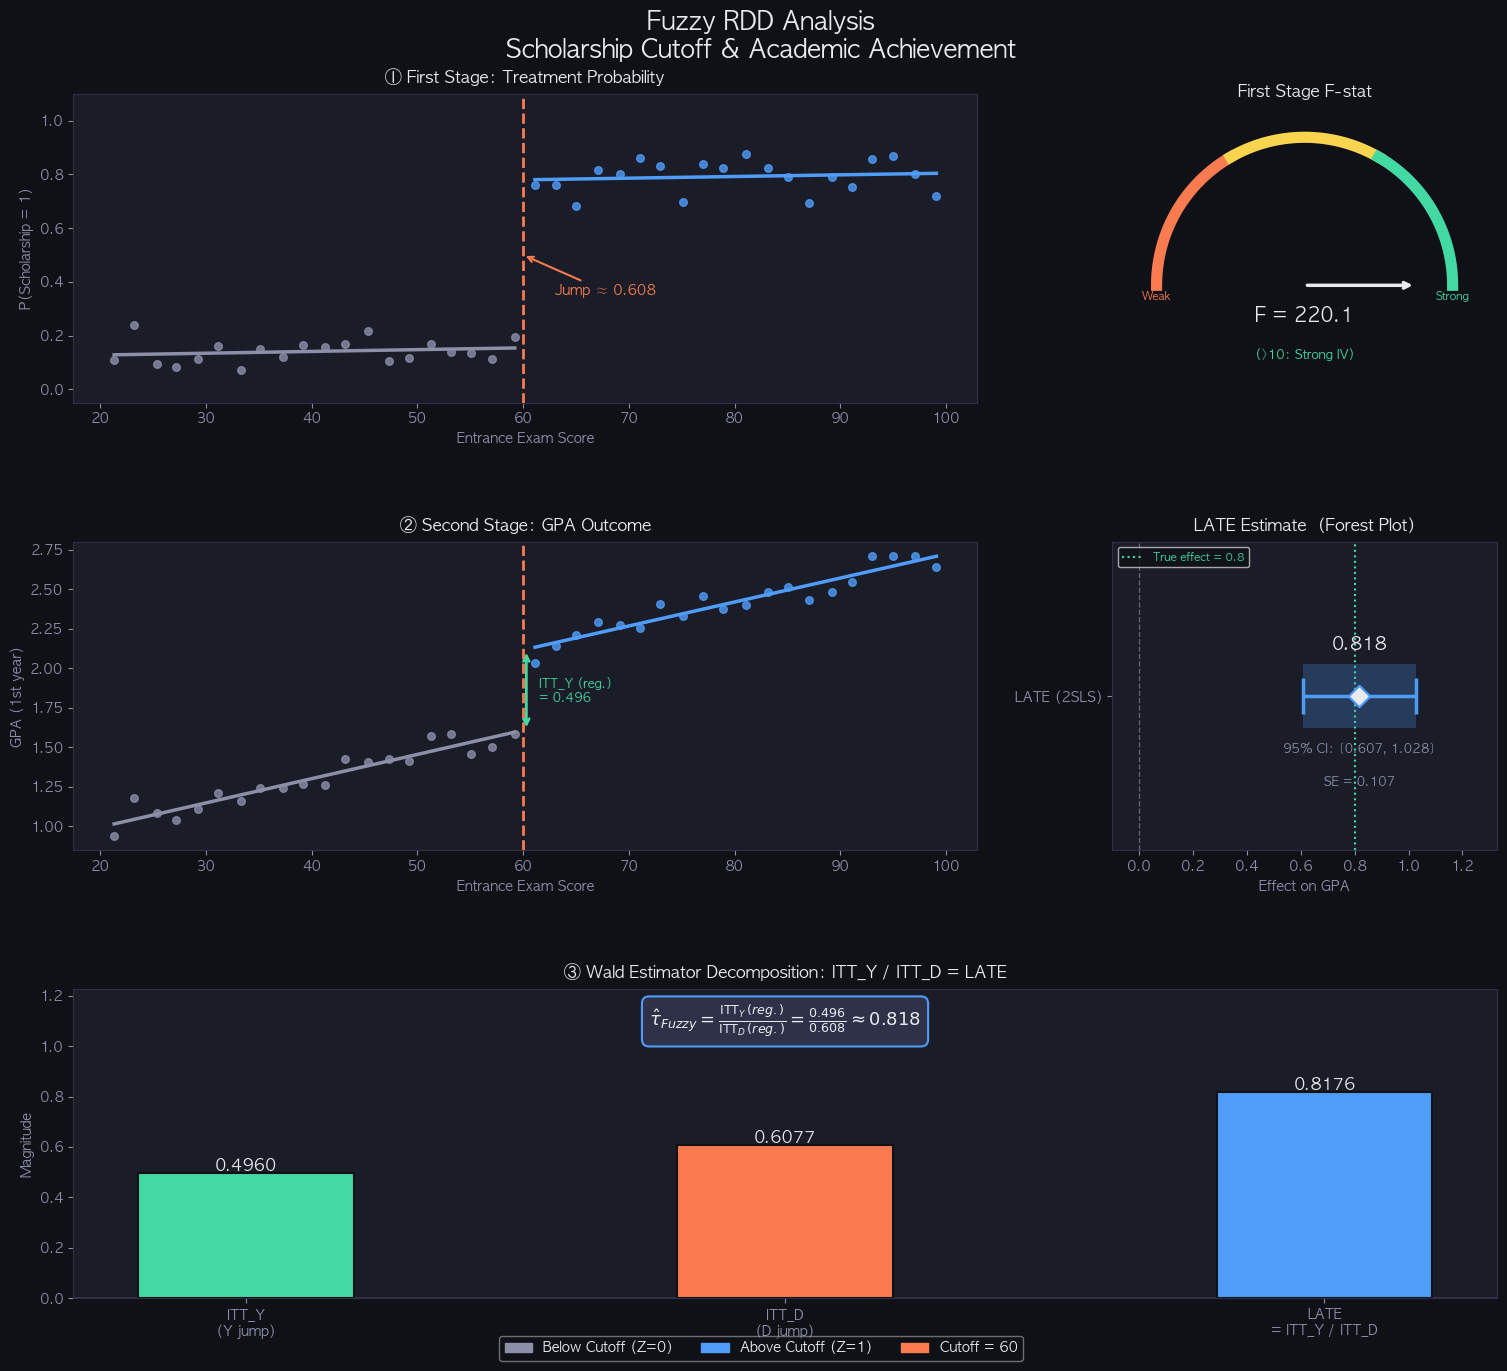

In [13]:
plot_fuzzy_rdd(true_effect=0.8)

# 활용 예시

## 사례 1: 항공편 운항 분석

| 항목 | 내용 |
|------|------|
| **연구 주제** | 도시 간 거리가 직항편 운항 확률에 미치는 인과적 효과 |
| **Running Variable** | 두 도시 공항 간의 거리 |
| **Cutoff** | 6,000 마일 |
| **Treatment** | 해당 구간의 직항편 운항 여부 |

### 핵심 내용

두 도시 간 거리가 6,000마일보다 짧으면 직항편이 존재할 확률이 크게 높아지지만,
100% 결정되는 것은 아닙니다.
즉, 컷오프에 의해 처치 확률이 불연속적으로 변하지만 완전히 결정되지 않는
**Fuzzy RD 디자인**에 해당합니다.

### 분석 방법 (2SLS)

- **1단계 (First Stage)**: 6,000마일 컷오프를 도구변수 $Z_i$로 사용하여 직항편 운항 여부 $D_i$ 예측
$$D_i = \alpha_0 + \alpha_1 Z_i + \alpha_2 (X_i - c) + \epsilon_i^{(1)}$$

- **2단계 (Second Stage)**: 예측된 $\hat{D}_i$를 사용하여 결과변수에 미치는 인과효과 추정
$$Y_i = \beta_0 + \beta_1 \hat{D}_i + \beta_2 (X_i - c) + \epsilon_i^{(2)}$$

- 러닝 변수에 대한 **컨트롤 함수(control function)**도 모델에 포함

## 사례 2: 공공 프로젝트 예산 및 감사 분석

| 항목 | 내용 |
|------|------|
| **연구 주제** | 공공 프로젝트 예산 규모가 모니터링·감사 증가에 미치는 인과적 효과 |
| **Running Variable** | 공공 프로젝트의 예산 규모 |
| **Cutoff** | 특정 기준 예산액 (SAT) |
| **Treatment** | 프로젝트에 대한 모니터링 및 감사 실시 여부 |

### 핵심 내용

프로젝트 예산이 특정 컷오프를 초과하면 감사 가능성이 높아지지만,
예산이 컷오프를 넘는다고 해서 감사가 100% 이루어지는 것은 아닙니다.
프로젝트 성격에 따라 감사 여부가 달라지므로, 이 역시 **Fuzzy RD 디자인**에 해당합니다.

### 분석 방법 (2SLS)

- **1단계 (First Stage)**: 예산이 SAT 컷오프를 초과하는지를 도구변수로 사용하여 감사 여부 예측
$$D_i = \alpha_0 + \alpha_1 \mathbf{1}[X_i \geq \text{SAT}] + \alpha_2 (X_i - \text{SAT}) + \epsilon_i^{(1)}$$

- **2단계 (Second Stage)**: 예측된 $\hat{D}_i$를 바탕으로 인과 효과 추정
$$Y_i = \beta_0 + \beta_1 \hat{D}_i + \beta_2 (X_i - \text{SAT}) + \epsilon_i^{(2)}$$

# 기타

## 약한 도구변수 진단

### F-통계량 (Rule of Thumb)

1단계 회귀의 $Z_i$ 계수에 대한 F-통계량을 확인합니다:

$$F = \frac{\hat{\alpha}_1^2 / \text{Var}(\hat{\alpha}_1)}{1}$$

- $F > 10$: 통상적으로 강한 도구변수로 판단 (Staiger & Stock, 1997)
- $F < 10$: 약한 도구변수 의심 → 추정 결과 신뢰 어려움

### Fuzzy RD 맥락에서의 해석

처치 확률의 점프 크기:

$$\hat{\Delta}_D = \lim_{x \downarrow c} \hat{\Pr}(D=1 \mid X=x) - \lim_{x \uparrow c} \hat{\Pr}(D=1 \mid X=x) = \hat{\alpha}_1$$

- 점프가 **클수록** (예: 0.5 이상) → 강한 도구변수
- 점프가 **작을수록** (예: 0.1 미만) → 약한 도구변수 위험

## 방법론 선택 플로우차트

### 의사결정 흐름

```
목표: 인과추론 (Causal Inference),
그리고 무작위 배정(Random Assignment)이 가능한가?
│
├── YES → Randomized Controlled Trial (RCT)
│
└── NO → 준실험적 연구 설계(Quasi-experimental design)가 가능한가?
          │
          ├── YES → 처치·통제 집단이 관측되는가?
          │         │
          │         ├── YES → 처치 전·후 패널 데이터가 있는가?
          │         │         │
          │         │         ├── YES → 평행 추세 가정이 성립하는가?
          │         │         │         │
          │         │         │         ├── YES → Difference-in-Differences (DiD) ✅
          │         │         │         │
          │         │         │         └── NO → DID + Matching  또는  Synthetic Control ✅
          │         │         │
          │         │         └── NO → 처치가 임의적 임계값(threshold)으로 배정되는가?
          │         │                   │
          │         │                   ├── YES → Regression Discontinuity (RDD) ✅
          │         │                   │
          │         │                   └── NO → (해당 없음)
          │         │
          │         └── NO → 처치 전·후 시계열 데이터가 있는가?
          │                   │
          │                   ├── YES → Interrupted Time-Series Analysis ✅
          │                   │
          │                   └── NO → Not feasible ❌
          │
          └── NO → 처치를 유발하는 도구변수(IV)가 존재하는가?
                    │
                    ├── YES → Two-Stage Least Squares (2SLS)
                    │          또는 Selection Bias Correction Method ✅
                    │
                    └── NO → 연구 환경이 명확한가?
                              (이진 처치, 집단 정의, 충분한 표본)
                              │
                              ├── YES → Matching ✅
                              │
                              └── NO → Regression ✅
```

### 방법론 분류 요약

| 범주 | 방법론 |
|------|--------|
| **준실험 (Quasi-Experiments)** | DiD, DiD + Matching, Synthetic Control, RDD, Interrupted Time-Series |
| **도구변수 (Instrumental Variable)** | 2SLS, Selection Bias Correction |
| **관측 가능 선택 (Selection on Observables)** | Matching, Regression |

## RDD vs DiD vs Synthetic Control 비교

### 핵심 비교표

| | **RDD** | **DiD** | **Synthetic Control** |
|---|---|---|---|
| **핵심 아이디어** | 컷오프 근방에서 처치 배정이 준-랜덤 | 처치·통제 집단의 평행 추세 가정 | 통제 집단의 가중 결합으로 반사실 구성 |
| **식별 전략** | 임계값 근방의 불연속성 | 시간 × 처치 집단 간 차이의 차이 | 처치 전 데이터로 합성 통제집단 구성 |
| **필요 데이터** | 횡단면(cross-section)으로도 가능 | 패널 데이터 (처치 전·후) | 패널 데이터 (처치 전 기간이 길수록 유리) |
| **처치 단위 수** | 제한 없음 | 제한 없음 | 처치 단위가 **1개**여도 가능 |
| **외부 타당성** | **낮음** (컷오프 근방 LATE만 추정) | 중간 (처치 집단 전체의 ATT) | 중간 (해당 처치 단위의 효과) |
| **내부 타당성** | **높음** (준-랜덤 배정에 가까움) | 평행 추세 가정에 의존 | 처치 전 적합도에 의존 |
| **주요 가정** | 컷오프 근방 연속성, 조작 불가 | 평행 추세 (parallel trends) | 볼록 결합(convex hull) 내 처치 단위 |
| **가정의 검증 가능성** | 비교적 용이 (McCrary test 등) | 사전 추세 검정으로 부분 검증 | 처치 전 적합도로 부분 검증 |
| **표본 효율성** | **낮음** (컷오프 근방만 사용) | 전체 표본 활용 | 전체 처치 전 기간 활용 |
| **적용 상황** | 명확한 규칙·임계값이 존재할 때 | 정책 시행 전·후 비교 가능할 때 | 처치 단위가 소수일 때 |

### RDD만의 강점

#### 가정이 투명하고 검증 가능하다
DiD의 평행 추세 가정은 **반사실(counterfactual)에 대한 가정**이므로 근본적으로 검증 불가능합니다.
반면 RDD는 아래와 같이 **관측 가능한 데이터로 직접 검증**할 수 있습니다.

| 검증 방법 | 내용 |
|-----------|------|
| **McCrary (2008) Density Test** | 러닝 변수의 분포가 컷오프에서 불연속인지 확인 (조작 여부 검정) |
| **Placebo Cutoff Test** | 가짜 컷오프에서는 불연속이 없어야 함 |
| **Covariate Smoothness Test** | 공변량이 컷오프에서 연속이어야 함 |

#### 준-실험적 설계에 가장 가깝다
컷오프 근방에서는 러닝 변수의 값이 미세하게 다를 뿐이므로,
처치·통제 집단이 **거의 동일한 개체**라고 볼 수 있습니다.
이는 무작위 배정(RCT)에 가장 근접한 관측 연구 설계입니다.

$$\text{RCT} \approx \text{RDD} > \text{DiD} \approx \text{Synthetic Control}$$

(인과추론의 신뢰도 측면에서)

#### 패널 데이터가 불필요하다
DiD와 Synthetic Control은 **처치 전·후의 시계열 데이터**가 필요하지만,
RDD는 **횡단면 데이터 하나**만으로도 인과효과 추정이 가능합니다.

### RDD의 한계 (trade-off)

| 한계 | 설명 |
|------|------|
| **외부 타당성 제한** | 컷오프 근방 순응자의 LATE만 추정 → 모집단 전체로 일반화 어려움 |
| **표본 낭비** | 컷오프에서 멀리 떨어진 관측치는 분석에 기여하지 못함 |
| **컷오프 필요** | 명확한 임계값이 존재하지 않으면 적용 자체가 불가능 |
| **조작 가능성** | 개체가 컷오프를 인식하고 러닝 변수를 조작할 유인이 있을 수 있음 |

### 방법론 선택 가이드

```
명확한 임계값·규칙이 존재하는가?
        ├── YES → RDD 우선 고려
        └── NO
              ├── 처치 단위가 소수(1~5개)인가?
              │         └── YES → Synthetic Control
              └── 패널 데이터 + 다수 처치 단위?
                          └── YES → DiD
```

# 참고자료

* [인과추론의 데이터과학(Youtube)](https://www.youtube.com/watch?v=8SIoMJTmO3A)